In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import mglearn
from sklearn.model_selection import train_test_split

## Metrics for Binary Classification

## Imbalanced datasets

In [2]:
from sklearn.datasets import load_digits

digits = load_digits()
y = digits.target == 9

x_train, x_test, y_train, y_test = train_test_split(
    digits.data, y, random_state=0)

from sklearn.dummy import DummyClassifier
dummy_majority = DummyClassifier(strategy='most_frequent').fit(x_train, y_train)
pred_most_frequent = dummy_majority.predict(x_test)
print('Unique predicted labels: {}'.format(np.unique(pred_most_frequent)))
print('Test score: {:.2f}'.format(dummy_majority.score(x_test, y_test)))

Unique predicted labels: [False]
Test score: 0.90


In [3]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=2).fit(x_train, y_train)
pred_tree = tree.predict(x_test)
print('Test score: {:.2f}'.format(tree.score(x_test, y_test)))

Test score: 0.92


In [4]:
from sklearn.linear_model import LogisticRegression

dummy = DummyClassifier().fit(x_train, y_train)
pred_dummy = dummy.predict(x_test)
print('dummy score: {:.2f}'.format(dummy.score(x_test, y_test)))

logreg = LogisticRegression(C=0.1).fit(x_train, y_train)
pred_logreg = logreg.predict(x_test)
print('logreg score: {:.2f}'.format(logreg.score(x_test, y_test)))

dummy score: 0.90
logreg score: 0.98


C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Confusion matrices

In [5]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(y_test, pred_logreg)
print('Confusion matrix:\n{}'.format(confusion))

Confusion matrix:
[[402   1]
 [  6  41]]


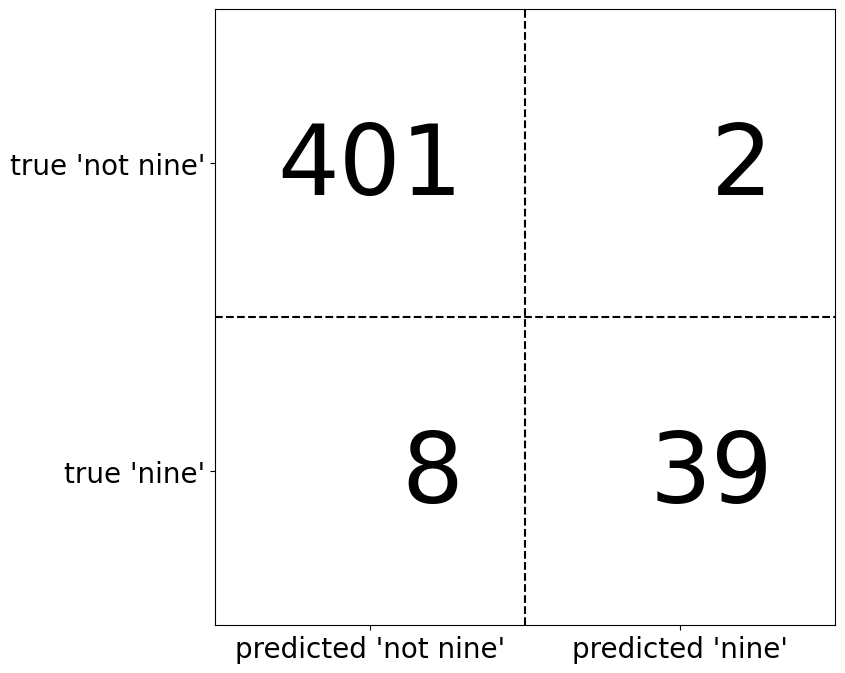

In [6]:
mglearn.plots.plot_confusion_matrix_illustration()

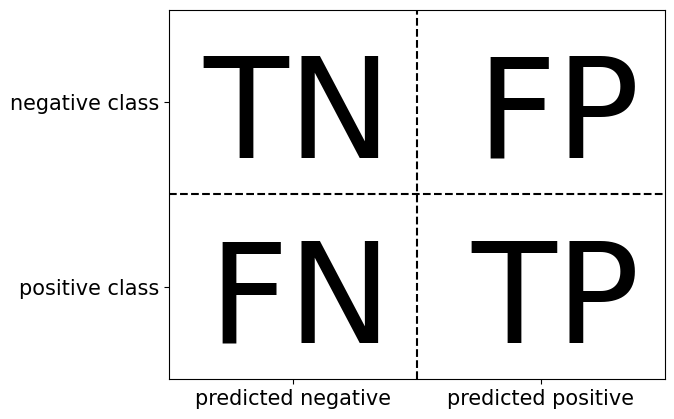

In [7]:
mglearn.plots.plot_binary_confusion_matrix()

In [8]:
print('Most frequent class:')
print(confusion_matrix(y_test, pred_most_frequent))
print('\nDummy model:')
print(confusion_matrix(y_test, pred_dummy))
print('\nDecision tree')
print(confusion_matrix(y_test, pred_tree))
print('\nLogistc Regression')
print(confusion_matrix(y_test, pred_logreg))

Most frequent class:
[[403   0]
 [ 47   0]]

Dummy model:
[[403   0]
 [ 47   0]]

Decision tree
[[390  13]
 [ 24  23]]

Logistc Regression
[[402   1]
 [  6  41]]


In [9]:
from sklearn.metrics import f1_score

print('f1 score most frequent: {:.2f}'.format(
        f1_score(y_test, pred_most_frequent)))
print('f1 score dummy: {:.2f}'.format(f1_score(y_test, pred_dummy)))
print('f1 score tree: {:.2f}'.format(f1_score(y_test, pred_tree)))
print('f1 score logistic regression: {:.2f}'.format(
        f1_score(y_test, pred_logreg)))

f1 score most frequent: 0.00
f1 score dummy: 0.00
f1 score tree: 0.55
f1 score logistic regression: 0.92


In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_most_frequent,
                           target_names=['not nine', 'nine']))

              precision    recall  f1-score   support

    not nine       0.90      1.00      0.94       403
        nine       0.00      0.00      0.00        47

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.90      0.85       450



C:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [11]:
print(classification_report(y_test, pred_dummy,
                           target_names=['not nine', 'nine']))


              precision    recall  f1-score   support

    not nine       0.90      1.00      0.94       403
        nine       0.00      0.00      0.00        47

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.90      0.85       450



C:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [12]:
print(classification_report(y_test, pred_logreg,
                           target_names=['not nine', 'nine']))

              precision    recall  f1-score   support

    not nine       0.99      1.00      0.99       403
        nine       0.98      0.87      0.92        47

    accuracy                           0.98       450
   macro avg       0.98      0.93      0.96       450
weighted avg       0.98      0.98      0.98       450



## taking uncertainty into account

In [39]:
from mglearn.datasets import make_blobs
from sklearn.svm import SVC

x, y = make_blobs(n_samples=(400, 50), cluster_std=[7, 2],
                 random_state=22)

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)
svc = SVC(gamma=.05).fit(x_train, y_train)

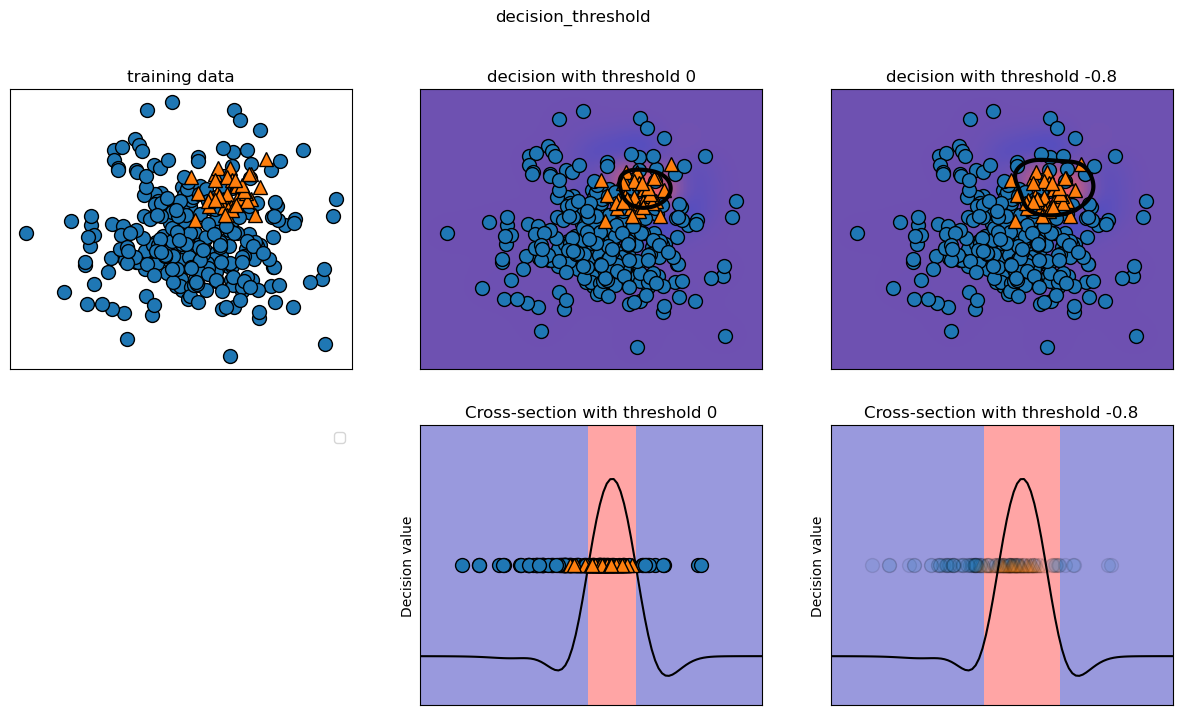

In [14]:
mglearn.plots.plot_decision_threshold()

In [15]:
print(classification_report(y_test, svc.predict(x_test)))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       104
           1       0.35      0.67      0.46         9

    accuracy                           0.88       113
   macro avg       0.66      0.78      0.70       113
weighted avg       0.92      0.88      0.89       113



In [16]:
y_pred_lower_threshold = svc.decision_function(x_test) > -.8

In [17]:
print(classification_report(y_test, y_pred_lower_threshold))

              precision    recall  f1-score   support

           0       1.00      0.82      0.90       104
           1       0.32      1.00      0.49         9

    accuracy                           0.83       113
   macro avg       0.66      0.91      0.69       113
weighted avg       0.95      0.83      0.87       113



## Precision-recall curves and ROC curves

Text(0, 0.5, 'Recall')

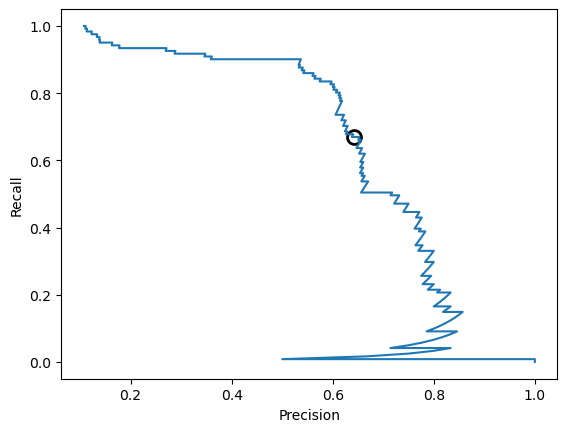

In [40]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(
    y_test, svc.decision_function(x_test))

# use more data points for a smoother curve
x, y = make_blobs(n_samples=(4000, 500), cluster_std=[7, 2],
                 random_state=22)
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)
svc = SVC(gamma=.05).fit(x_train, y_train)
precision, recall, thresholds = precision_recall_curve(
    y_test, svc.decision_function(x_test))

# find threshold closest to zero
close_zero = np.argmin(np.abs(thresholds))
plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10,
        label='threshold zero', fillstyle='none', c='k', mew=2)

plt.plot(precision, recall, label='precision recall curve')
plt.xlabel('Precision')
plt.ylabel('Recall')

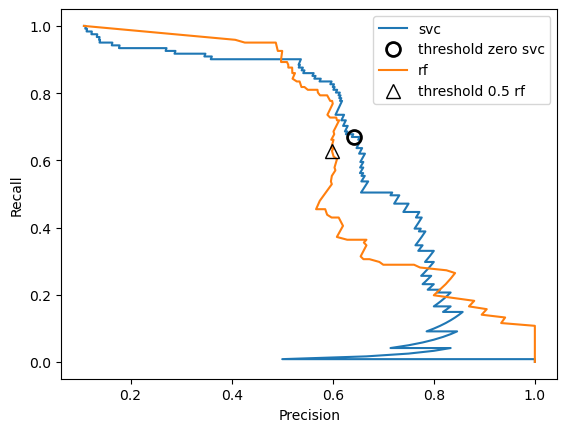

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=0, max_features=2)
rf.fit(x_train, y_train)

# RandomForestClassifier has predict_proba, but not decision function
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_test, rf.predict_proba(x_test)[:, 1])

plt.plot(precision, recall, label='svc')

plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10,
        label='threshold zero svc', fillstyle='none', c='k', mew=2)

plt.plot(precision_rf, recall_rf, label='rf')

close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(precision_rf[close_default_rf], recall_rf[close_default_rf], '^', c='k',
         markersize=10, label='threshold 0.5 rf', fillstyle='none')
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.legend(loc='best')

In [42]:
print('f1_score of random forest: {:.3f}'.format(
    f1_score(y_test, rf.predict(x_test))))
print('f1_score of svc: {:.3f}'.format(f1_score(y_test, svc.predict(x_test))))

f1_score of random forest: 0.610
f1_score of svc: 0.656


In [43]:
from sklearn.metrics import average_precision_score
ap_rf = average_precision_score(y_test, rf.predict_proba(x_test)[:, 1])
ap_svc = average_precision_score(y_test, svc.decision_function(x_test))
print('Average precision of random forest: {:.3f}'.format(ap_rf))
print('Average precision of svc: {:.3f}'.format(ap_svc))

Average precision of random forest: 0.660
Average precision of svc: 0.666


## Reveiver operating characteristics (ROC) and AUC


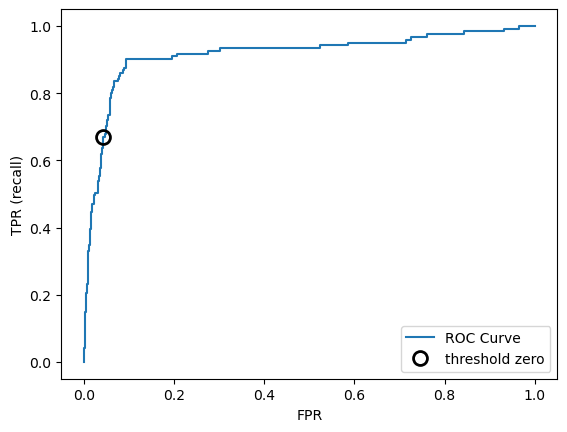

In [44]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, svc.decision_function(x_test))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('FPR')
plt.ylabel('TPR (recall)')

# find threshold closet to zero
close_zero = np.argmin(np.abs(thresholds))
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10,
        label='threshold zero', fillstyle='none', c='k', mew=2)
plt.legend(loc=4)

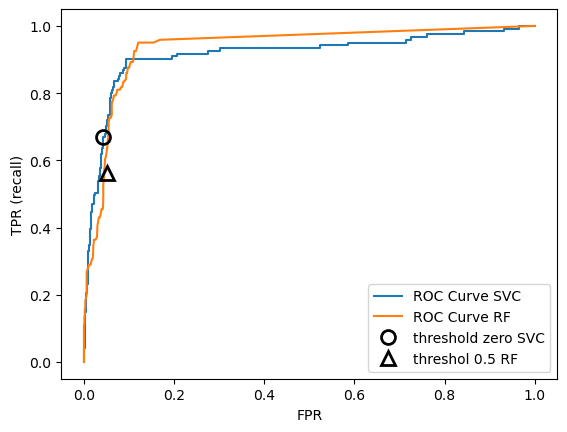

In [45]:
from sklearn.metrics import roc_curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf.predict_proba(x_test)[:, 1])

plt.plot(fpr, tpr, label='ROC Curve SVC')
plt.plot(fpr_rf, tpr_rf, label='ROC Curve RF')

plt.xlabel('FPR')
plt.ylabel('TPR (recall)')
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10,
        label='threshold zero SVC', fillstyle='none', c='k', mew=2)
close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(fpr_rf[close_default_rf], tpr[close_default_rf], '^', markersize=10,
        label='threshol 0.5 RF', fillstyle='none', c='k', mew=2)

plt.legend(loc=4)

In [46]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, rf.predict_proba(x_test)[:, 1])
svc_auc = roc_auc_score(y_test, svc.decision_function(x_test))
print('AUC for Random Forest: {:.3f}'.format(rf_auc))
print('AUC for SVC: {:.3f}'.format(svc_auc))


AUC for Random Forest: 0.937
AUC for SVC: 0.916


gamma = 1.00 accuracy = 0.90 AUC = 0.50
gamma = 0.05 accuracy = 0.90 AUC = 1.00
gamma = 0.01 accuracy = 0.90 AUC = 1.00


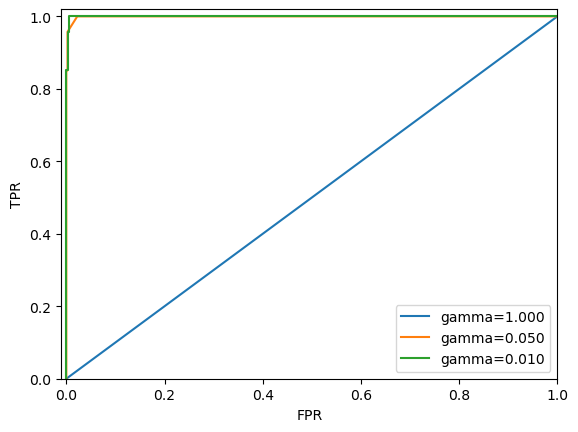

In [54]:
from sklearn.datasets import load_digits
from sklearn.svm import SVC

digits = load_digits()
y = digits.target == 9

x_train, x_test, y_train, y_test = train_test_split(
    digits.data, y, random_state=0)

plt.figure()

for gamma in [1, 0.05, 0.01]:
    svc = SVC(gamma=gamma).fit(x_train, y_train)
    accuracy = svc.score(x_test, y_test)
    auc = roc_auc_score(y_test, svc.decision_function(x_test))
    fpr, tpr, _ = roc_curve(y_test, svc.decision_function(x_test))
    print('gamma = {:.2f} accuracy = {:.2f} AUC = {:.2f}'.format(gamma, accuracy, auc))
    plt.plot(fpr, tpr, label='gamma={:.3f}'.format(gamma))
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.xlim(-0.01, 1)
    plt.ylim(0, 1.02)
    plt.legend(loc='best')

## Metrics for Multiclass Classification

In [57]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

x_train, x_test, y_train, y_test = train_test_split(
    digits.data, digits.target, random_state=0)
lr = LogisticRegression().fit(x_train, y_train)
pred = lr.predict(x_test)
print('Accuracy: {:.3f}'.format(accuracy_score(y_test, pred)))
print('Confusion matrix:\n{}'.format(confusion_matrix(y_test, pred)))

Accuracy: 0.951
Confusion matrix:
[[37  0  0  0  0  0  0  0  0  0]
 [ 0 40  0  0  0  0  0  0  2  1]
 [ 0  1 40  3  0  0  0  0  0  0]
 [ 0  0  0 43  0  0  0  0  1  1]
 [ 0  0  0  0 37  0  0  1  0  0]
 [ 0  0  0  0  0 46  0  0  0  2]
 [ 0  1  0  0  0  0 51  0  0  0]
 [ 0  0  0  1  1  0  0 46  0  0]
 [ 0  3  1  0  0  0  0  0 43  1]
 [ 0  0  0  0  0  1  0  0  1 45]]


C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


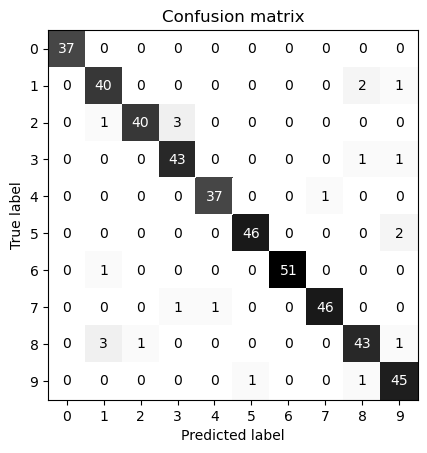

In [59]:
scores_image = mglearn.tools.heatmap(
    confusion_matrix(y_test, pred), xlabel='Predicted label',
    ylabel='True label', xticklabels=digits.target_names,
    yticklabels=digits.target_names, cmap=plt.cm.gray_r, fmt="%d")
plt.title('Confusion matrix')
plt.gca().invert_yaxis()

In [60]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.89      0.93      0.91        43
           2       0.98      0.91      0.94        44
           3       0.91      0.96      0.93        45
           4       0.97      0.97      0.97        38
           5       0.98      0.96      0.97        48
           6       1.00      0.98      0.99        52
           7       0.98      0.96      0.97        48
           8       0.91      0.90      0.91        48
           9       0.90      0.96      0.93        47

    accuracy                           0.95       450
   macro avg       0.95      0.95      0.95       450
weighted avg       0.95      0.95      0.95       450



In [61]:
print('Micro average f1 score: {:.3f}'.format(
    f1_score(y_test, pred, average='micro')))
print('Macro average f1 score: {:.3f}'.format(
    f1_score(y_test, pred, average='macro')))

Micro average f1 score: 0.951
Macro average f1 score: 0.952


## Regression Metrics

## Using Evaluation Metrics in Model Selection

In [63]:
from sklearn.model_selection import cross_val_score

# default scoring for classification in accuracy
print('Default scoring: {}'.format(
    cross_val_score(SVC(), digits.data, digits.target == 9)))

# providing scoring='accuracy' doesn't change the results
explicit_accuracy = cross_val_score(SVC(), digits.data, digits.target == 9,
                                   scoring='accuracy')
print('Explicit accuracy scoring: {}'.format(explicit_accuracy))
roc_auc = cross_val_score(SVC(), digits.data, digits.target == 9,
                         scoring='roc_auc')
print('AUC scoring: {}'.format(roc_auc))

Default scoring: [0.975      0.99166667 1.         0.99442897 0.98050139]
Explicit accuracy scoring: [0.975      0.99166667 1.         0.99442897 0.98050139]
AUC scoring: [0.99717078 0.99854252 1.         0.999828   0.98400413]


In [70]:
from sklearn.model_selection import GridSearchCV

x_train, x_test, y_train, y_test = train_test_split(
    digits.data, digits.target == 9, random_state=0)

# we provide a somewhat bad grid to illustrate the point:
param_grid = {'gamma': [0.0001, 0.01, 0.1, 1, 10]}

# using the default scoring of accuracy
grid = GridSearchCV(SVC(), param_grid=param_grid)
grid.fit(x_train, y_train)
print('Grid-Search with accuracy')
print('Best parameters: ', grid.best_params_)
print('Best cross-validation score (accuracy): {:.3f}'.format(grid.best_score_))
print('Test set AUC: {:.3f}'.format(
    roc_auc_score(y_test, grid.decision_function(x_test))))
print('Test set acuracy: {:.3f}'.format(grid.score(x_test, y_test)))

Grid-Search with accuracy
Best parameters:  {'gamma': 0.0001}
Best cross-validation score (accuracy): 0.976
Test set AUC: 0.992
Test set acuracy: 0.973


In [74]:
# using AUC scoring instead:
grid = GridSearchCV(SVC(), param_grid=param_grid, scoring='roc_auc')
grid.fit(x_train, y_train)
print('\nGrid-Search with AUC')
print('Best parameters:', grid.best_params_)
print('Best cross-validation score (AUC): {:.3f}'.format(grid.best_score_))
print('Test set AUC: {:.3f}'.format(
    roc_auc_score(y_test, grid.decision_function(x_test))))
print('Test set accuracy: {:.3f}'.format(grid.score(x_test, y_test)))


Grid-Search with AUC
Best parameters: {'gamma': 0.01}
Best cross-validation score (AUC): 0.998
Test set AUC: 1.000
Test set accuracy: 1.000


In [76]:
from sklearn.metrics import SCORERS
print('Available scorers:\n{}'.format(sorted(SCORERS.keys())))

Available scorers:
['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'max_error', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples', 'recall_weighted', 'roc_auc', 'roc_auc_ovo', 